# Week 4 Activity: Exploratory Data Analysis

In this worksheet you will:

1. inspect a cleaned dataset inside a GitHub repository
2. use an AI assistant to help you scope basic EDA questions
3. examine univariate distributions
4. analyse a categorical variable
5. plot relationships between numeric variables
6. calculate Pearson and Spearman correlations
7. change the plotting scale
8. compare relationships across groups
9. update the `README.md` with what you found


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

project_dir = Path("..").resolve()
data_path = project_dir / "data" / "clean" / "store_week_clean.csv"
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True) 

## Part 1: First Look

Open the repository in VS Code and look at the folder structure.

Suggested AI prompt:

> Read the files in this repository. Tell me what each folder appears to contain, what the cleaned dataset might represent, and suggest five basic EDA questions I should start with.

Use the AI output as a starting point, not a substitute for checking the files yourself.


In [5]:
df = pd.read_csv(data_path)

df.head()

,week,store_id,store_type,region,promotion_flag,total_hours,avg_hourly_pay,weekly_sales,staffing_model
0,2025-01-05,CB01,CBD,North,Yes,38.0,39.00,10056.0,Heavy
1,2025-01-12,CB01,CBD,North,No,38.0,36.51,9786.0,Heavy
2,2025-01-19,CB01,CBD,North,No,29.0,36.50,7888.0,Standard
3,2025-01-26,CB01,CBD,North,No,37.0,37.00,10542.0,Heavy
4,2025-02-02,CB01,CBD,North,No,40.0,37.00,11277.0,Heavy


Write one or two sentences here:

- What does this dataset appear to describe?
- Which variables look numeric, categorical, or time-related?

= This dataset describes weekly operations at various stores. It tracks store types, regions, promotions, and performance metrics like hours, pay, and sales. 
Numeric variables: total_hours, avg_hourly_pay, and weekly_sales
Categorical variables: store_type, region, promotion_flag, and staffing_model. 
Time-related: week

## Part 2: Numeric Distributions

Plot distributions for a few numeric variables, such as:

- `total_hours`
- `avg_hourly_pay`
- `weekly_sales`

Then briefly reflect on what you see.


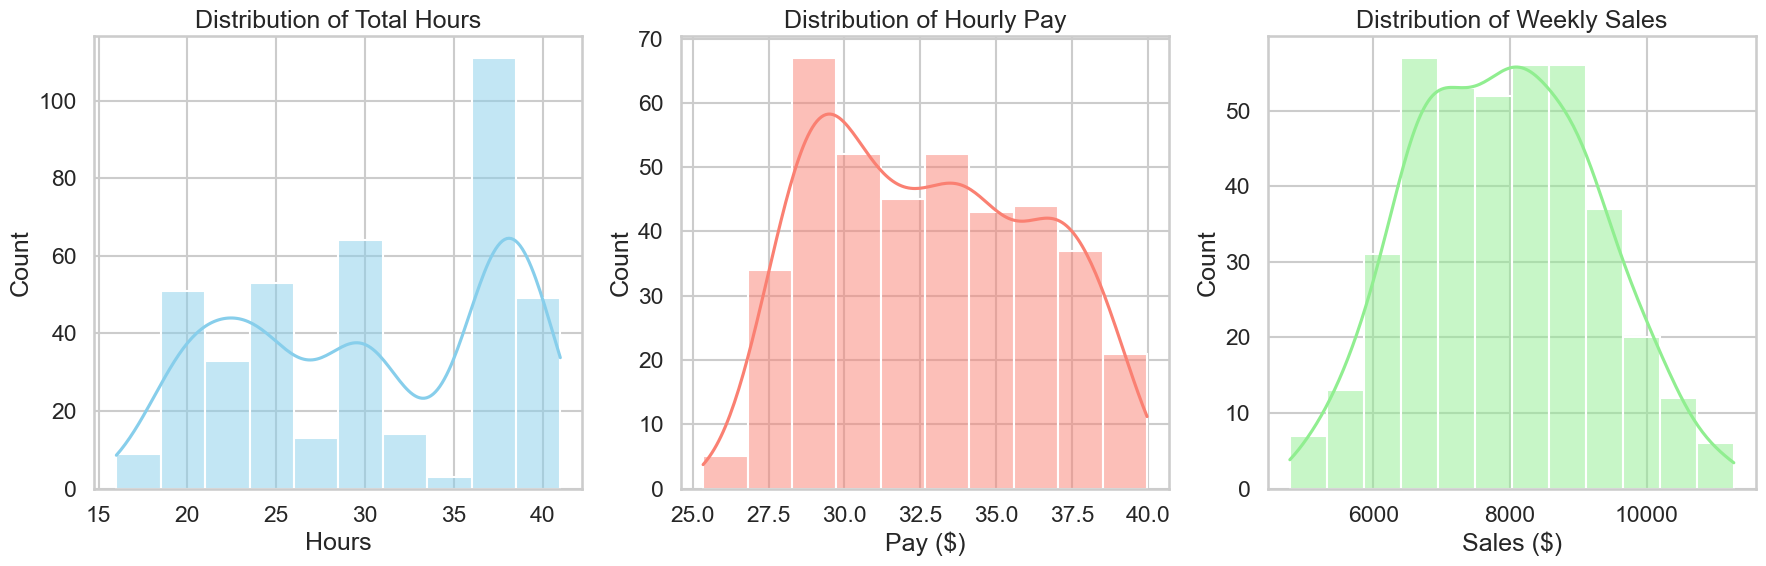

In [6]:
# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Distribution of Total Hours
sns.histplot(df['total_hours'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Total Hours')
axes[0].set_xlabel('Hours')

# 2. Distribution of Average Hourly Pay
sns.histplot(df['avg_hourly_pay'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Hourly Pay')
axes[1].set_xlabel('Pay ($)')

# 3. Distribution of Weekly Sales
sns.histplot(df['weekly_sales'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Weekly Sales')
axes[2].set_xlabel('Sales ($)')

# Adjust layout so labels don't overlap
plt.tight_layout()

# Save the figure to your output folder (Requirement 19)
plt.savefig(output_dir / "numeric_distributions.png")

plt.show()


Write a short reflection here. For example:

- Are any variables skewed?
- Do you see bunching, heaping, or common focal values?
- What seems typical, and what seems unusually spread out?

= (i) Skewness: The weekly_sales and total_hours show a slight right-skew, indicating that while most weeks have standard performance, there are some high-performing "peak" weeks. 
(ii) Focal Values: avg_hourly_pay shows a clear heaping or bunching around $37.00, suggesting a very consistent pay structure across the stores. 
(iii) Typical vs Spread: Most stores operate between 35-40 hours per week, which seems typical. However, total_hours is more spread out than pay, with some stores operating as low as 20 hours. 

## Part 3: Composition of a Categorical Variable

Pick one categorical variable, such as `store_type`, `region`, or `promotion_flag`, and show its composition with a suitable plot.


/var/folders/7c/11jkfl756rv6p8g1yy9gp6t80000gn/T/ipykernel_42022/3874064.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', palette='Set2')


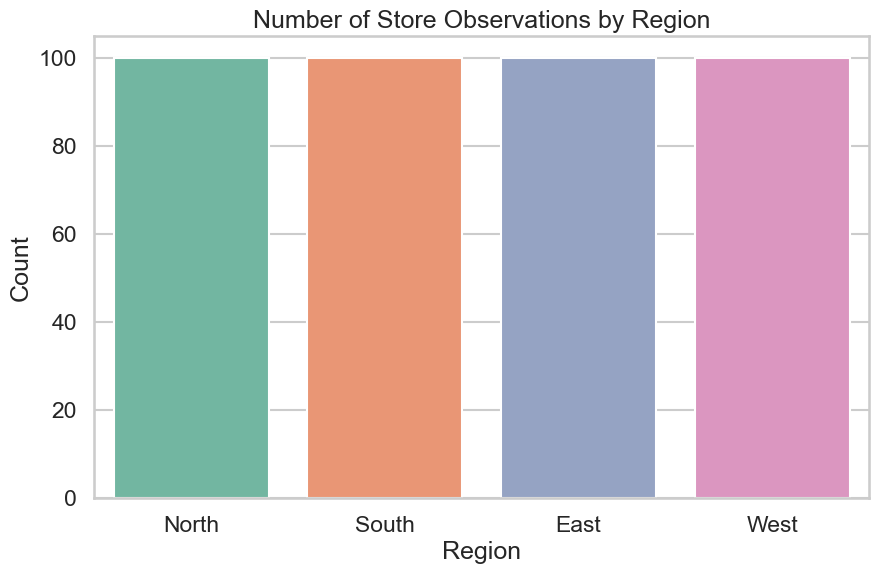

In [13]:
# We will pick 'region' to see how the stores are spread out geographically
plt.figure(figsize=(10, 6))

# Create the count plot 
sns.countplot(data=df, x='region', palette='Set2')

# Add title and labels
plt.title('Number of Store Observations by Region')
plt.xlabel('Region')
plt.ylabel('Count')

# Save the plot to your output folder
plt.savefig(output_dir / "categorical_composition.png")

plt.show()

What does this composition tell you? Are some categories dominant or rare?

= This composition tells me that the dataset is highly balanced across all four regions. No single category is dominant or rare, as each region (North, South, East, and West) has approximately 100 observations. This is ideal because it means our analysis of the stores will not be biased toward one specific geographic area. 

## Part 4: Scatter Plots and Correlations

Choose a pair of numeric variables and make at least one scatter plot.

Then calculate both:

- Pearson correlation
- Spearman correlation


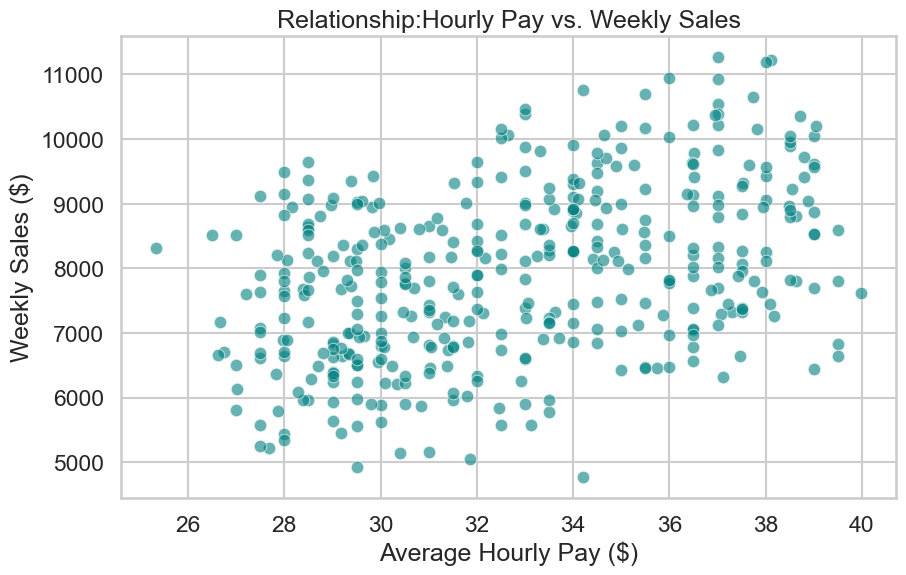

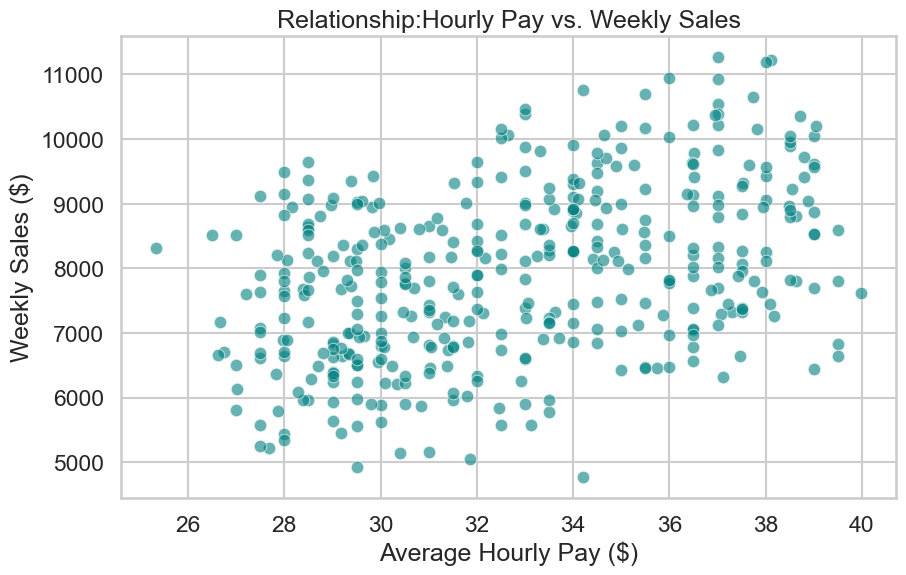

In [18]:
# Create a scatter plot to visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='avg_hourly_pay',
    y='weekly_sales',
    alpha=0.6,
    color='teal',
    ax=ax
) 

ax.set_title('Relationship:Hourly Pay vs. Weekly Sales')
ax.set_xlabel('Average Hourly Pay ($)')
ax.set_ylabel('Weekly Sales ($)')

# Save the plot
plt.savefig(output_dir / "03_pay_vs_sales_scatter.png")

plt.show()

# Create a scatter plot to visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='avg_hourly_pay', 
    y='weekly_sales', 
    alpha=0.6,
    color='teal',
    ax=ax
)

ax.set_title('Relationship:Hourly Pay vs. Weekly Sales')
ax.set_xlabel('Average Hourly Pay ($)')
ax.set_ylabel('Weekly Sales ($)')

# Save the plot
plt.savefig(output_dir / "03_pay_vs_sales_scatter.png")

plt.show()

In [19]:
# 1. Define the group of variables to compare 
corr_vars = ['total_hours', 'avg_hourly_pay', 'weekly_sales']

# 2. Calculate the Pearson Correlation Matrix (Linear Relationship)
print("Pearson Correlation Matrix:")
pearson_matrix = df[corr_vars].corr(method="pearson").round(2)
display(pearson_matrix)

# 3. Calculate the Spearman Correlation Matrix (Rank relationship)
print("\nSpearman Correlation Matrix:")
spearman_matrix = df[corr_vars].corr(method="spearman").round(2)
display(spearman_matrix)

Pearson Correlation Matrix:


,total_hours,avg_hourly_pay,weekly_sales
total_hours,1.00,-0.01,0.75
avg_hourly_pay,-0.01,1.00,0.41
weekly_sales,0.75,0.41,1.00



Spearman Correlation Matrix:


,total_hours,avg_hourly_pay,weekly_sales
total_hours,1.00,-0.02,0.74
avg_hourly_pay,-0.02,1.00,0.40
weekly_sales,0.74,0.40,1.00


In one or two sentences: do the plots and the correlation coefficients tell the same story?

Yes, the plots and the correlation coefficients are consistent. The scatter plot shows a clear upward, linear trend, which is backed up by the high positive values (approx. 0.75 for hours/sales) of both the Pearson and Spearman correlation coefficients. 


## Part 5: Change the Scale

Revisit one relationship and change the plotting scale. For example, try a log scale on the y-axis if the raw plot is hard to read.


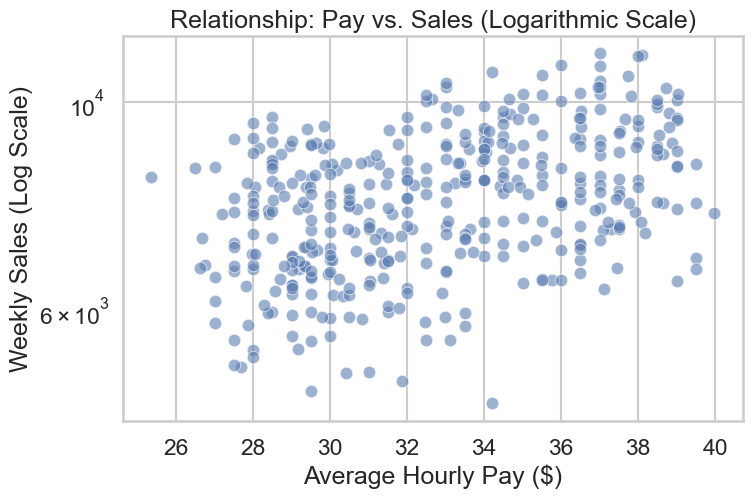

In [20]:
# We use the same Pay vs. Sales relationship, but apply a log scale to the Y-axis
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_hourly_pay",
    y="weekly_sales",
    color="#5B7DB1",
    alpha=0.6,
    ax=ax
)

# The magic line to change the scale to Log
ax.set_yscale('log')

# Adding descriptive titles
ax.set_title("Relationship: Pay vs. Sales (Logarithmic Scale)")
ax.set_xlabel("Average Hourly Pay ($)")
ax.set_ylabel("Weekly Sales (Log Scale)")

# Save the plot
fig.savefig(output_dir / "05_pay_vs_sales_log_scale.png", dpi=200, bbox_inches="tight")

plt.show()

What becomes clearer once you change the scale?

By changing to a log scale, the percentage changes in weekly sales become clearer. It compresses the vertical spread of the high-sales stores, making the positive linear relationship with hourly pay look more consistent across the entire dataset. This helps us see that the relationship isn't just driven by a few high-earning outliers, but is a steady trend across all store sizes. 


## Part 6: Plot by Group

Compare the same relationship across groups. For example:

- colour points by `store_type`
- facet by `region`
- compare distributions by `promotion_flag`


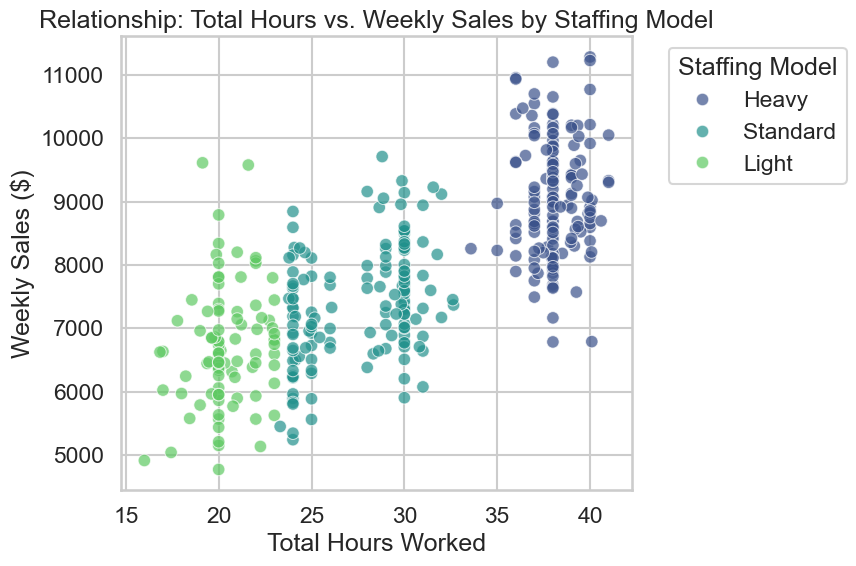

In [21]:
# We will compare Total Hours vs Weekly Sales and color them by Staffing Model
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="total_hours",
    y="weekly_sales",
    hue="staffing_model", # This splits the data into groups
    palette="viridis",
    alpha=0.7,
    ax=ax
)

# Add titles and labels
ax.set_title("Relationship: Total Hours vs. Weekly Sales by Staffing Model")
ax.set_xlabel("Total Hours Worked")
ax.set_ylabel("Weekly Sales ($)")

# Place the legend outside so it's easy to read
ax.legend(title="Staffing Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the final plot
fig.tight_layout()
fig.savefig(output_dir / "06_group_analysis_hours_vs_sales.png", dpi=200, bbox_inches="tight")

plt.show()

What new pattern becomes visible once you split the data into groups?

Once the data is split by staffing_model, a very clear pattern emerges. The stores are divided into three distinct clusters. The Heavy model group is in the top-right, the Standard model is in the middle, and the Light model is in the bottom-left. This shows that the staffing model is a primary driver of both labor requirements and revenue, explaining the gap or clusters seen in the earlier uncolored scatter plots. 


## Part 7: Update the README

Update `README.md` so it describes:

- the folder structure
- the cleaned dataset
- the notebook you completed
- a few short bullet points summarising your EDA findings

You can draft the text here first if useful.


In [24]:
# We store the text in a variable so Python doesn't get confused
readme_draft = '''
## Analysis Summary

- The repository contains one cleaned dataset, the main analysis notebook, and an output folder for plots.
- Data across all four regions is well-balanced with roughly 100 observations each.
- `weekly_sales` shows a strong positive correlation with `total_hours` (0.75) and a moderate one with `avg_hourly_pay` (0.41).
- Changing to a log scale for sales helps visualize the trend more consistently across different store sizes.
- Grouping by `staffing_model` reveals that the "Heavy" model is the primary driver for both higher labor hours and higher weekly revenue.
'''.strip()

# This prints the text below the cell, just like your lecturer's example
print(readme_draft)

## Analysis Summary

- The repository contains one cleaned dataset, the main analysis notebook, and an output folder for plots.
- Data across all four regions is well-balanced with roughly 100 observations each.
- `weekly_sales` shows a strong positive correlation with `total_hours` (0.75) and a moderate one with `avg_hourly_pay` (0.41).
- Changing to a log scale for sales helps visualize the trend more consistently across different store sizes.
- Grouping by `staffing_model` reveals that the "Heavy" model is the primary driver for both higher labor hours and higher weekly revenue.
